# Часть 1. Проверка гипотезы в Python и составление аналитической записки

После предобработки данных в SQL они готовы для проверки гипотезы в Python. Загрузим данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv.

Проверим наличие дубликатов в идентификаторах пользователей. Сравним размеры групп, их статистики и распределение.

Необходимо проверить следующую гипотезу: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза H0: Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза H1: Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

## Проверка гипотезы активности пользователей в Санкт-Петербурге и Москве.

- Автор: Рубцов Д.А.
- Дата: 24.04.2026

## Цели и задачи проекта

Целью проекта является проверка односторонней гипотезы о том, что пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы.

## Описание данных

Таблица `yandex_knigi_data.csv` содержит данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности и содержит столбцы:
- `city` — название города
- `puid` — уникальный индификатор пользователя
- `hours` — cреднее количество прослушанных часов пользователя

## Содержимое проекта

- Устанавливаем и импортируем необходимые библиотеки
- Загружаем таблицу `yandex_knigi_data.csv` в датафрейм `df`
- Проверяем наличие дубликатов, сравниваем размеры групп, их статистики и распределение.
- Проверяем гипотезу активности пользователей
- Делаем выводы в аналитической записке
---

## 1. Загрузка данных и знакомство с ними

Загрузим данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Добавляем и устанавливаем необходимые библиотеки
!pip install pandas
!pip install scipy
!pip install statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import norm
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency


In [2]:
# Создаем датафрейм
df = pd.read_csv('https://code.s3.yandex.net/datasets/yandex_knigi_data.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
print(df.head())
print()
print(df.info())

     city    puid       hours
0  Москва    9668   26.167776
1  Москва   16598   82.111217
2  Москва   80401    4.656906
3  Москва  140205    1.840556
4  Москва  248755  151.326434

<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   str    
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), str(1)
memory usage: 206.0 KB
None


In [3]:
print('Всего строк:', len(df))
print('Найдено дубликатов:', df['puid'].duplicated().sum())
df = df.drop_duplicates(subset=['puid'],keep='first')
print('Осталось строк после удаления дубликатов:', df['puid'].nunique())
df = df.reset_index(drop=True)

Всего строк: 8784
Найдено дубликатов: 244
Осталось строк после удаления дубликатов: 8540


In [4]:
df_mos = df[df['city'] == 'Москва']
df_spb = df[df['city'] == 'Санкт-Петербург']
print('Размер группы из Москвы:', len(df_mos))
print('Размер группы из Санкт-Петербурга:', len(df_spb))

Размер группы из Москвы: 6234
Размер группы из Санкт-Петербурга: 2306


In [5]:
print('Описание данных статистики по Москве','\n', df_mos.describe())
print()
print('Описание данных статистики по Санкт-Петербургу','\n', df_spb.describe())

Описание данных статистики по Москве 
                puid        hours
count  6.234000e+03  6234.000000
mean   1.123926e+13    10.881092
std    1.121386e+14    36.851683
min    9.668000e+03     0.000018
25%    3.139885e+08     0.059903
50%    8.730945e+08     0.924498
75%    1.510930e+09     5.939972
max    1.130000e+15   857.209373

Описание данных статистики по Санкт-Петербургу 
                puid        hours
count  2.306000e+03  2306.000000
mean   5.391234e+12    11.264433
std    7.787547e+13    39.831755
min    1.049230e+05     0.000025
25%    3.594025e+08     0.060173
50%    9.265005e+08     0.875355
75%    1.542720e+09     6.138424
max    1.130000e+15   978.764775


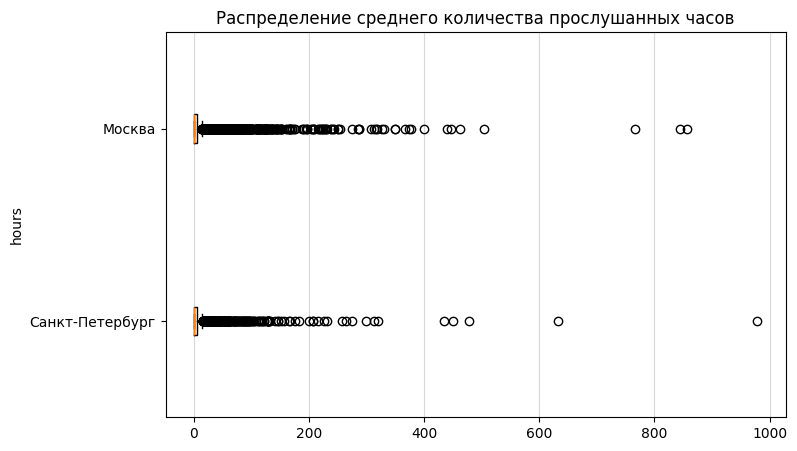

In [6]:
# Визуализируем распределение активности пользователей
data = [df_spb['hours'],df_mos['hours']]

plt.figure(figsize=(8,5))

plt.boxplot(
    data, 
    tick_labels=['Санкт-Петербург','Москва'], 
    vert=False
)

plt.title('Распределение cреднего количества прослушанных часов')
plt.ylabel('hours')
plt.grid(axis='x', alpha=0.5)

plt.show()

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуем статистически ее доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [7]:
# Определяем группы и проверяем гипотезу
metric_a = df[df['city'] =='Санкт-Петербург']['hours']
metric_b = df[df['city'] =='Москва']['hours']

alpha = 0.05

stat_ttest, p_value_ttest = ttest_ind(
    metric_a,
    metric_b,
    alternative='greater',
    equal_var=False
    )
print(f'p_value: {p_value_ttest}')
if p_value_ttest > alpha:
    print('Нулевая гипотеза находит подтверждение.')
    print('Разница в средней активности пользователей не является статистически значимой.')
else:
    print('Нулевая гипотеза не находит подтверждение.')
    print('Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.')

p_value: 0.34357081187663124
Нулевая гипотеза находит подтверждение.
Разница в средней активности пользователей не является статистически значимой.


## 3. Аналитическая записка

Для проверки гипотезы о средней активности пользователей в Санкт-Петербурге и Москве был выбран двухвыборочный *t-тест Стьюдента* с уровнем статистической значимости **5%**. Данный тест применим, поскольку выборки независимы, а стандартное отклонение приблизительно равное.
   
По итогу проведенного t-теста, `p_value` оказался равен **0.34**, что не дало основания отвергнуть нулевую гипотезу.
   
Вероятными причинами такого результата может быть тот факт, что для сравнения были выбраны два крупных города России со схожими географическими, культурно-историческими и социальными характеристиками. Все это могло повлиять на то, что пользователи обоих городов слушают книги примерно одинаковое количество времени.

# Часть 2. Анализ результатов A/B-тестирования

Теперь проанализировем другие данные. Представим, что к нам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория и даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Здесь задачей будет провести оценку результатов A/B-теста.

## Цели исследования.



Целью данного A/B тестирования является привлечение новых клиентов и увеличение числа продаж благодаря упрощению интерфейса онлайн-магазина BitMotion Kit.

## Загрузим данные и оценим их целостность.


In [8]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

## По таблице `ab_test_participants` оценим корректность проведения теста:

   3\.1 Выделим пользователей, участвующих в тесте, и проверим:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [9]:
# Выводим данные
print(participants.head())

            user_id group                  ab_test   device
0  0002CE61FF2C4011     B        interface_eu_test      Mac
1  001064FEAAB631A1     B  recommender_system_test  Android
2  001064FEAAB631A1     A        interface_eu_test  Android
3  0010A1C096941592     A  recommender_system_test  Android
4  001E72F50D1C48FA     A        interface_eu_test      Mac


In [10]:
print(participants.info())

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
 3   device   14525 non-null  str  
dtypes: str(4)
memory usage: 454.0 KB
None


In [11]:
# Формируем тестовые группы
group_a = participants[(
    participants['ab_test']=='interface_eu_test')
    &(participants['group']=='A')]['user_id'].nunique()
group_b = participants[(
    participants['ab_test']=='interface_eu_test')
    &(participants['group']=='B')]['user_id'].nunique()
# Вычисляем разницу между группами
ab_diff = round((100.0*(abs(group_a - group_b)/group_a)),2)
print('Пользователей в группе A:',group_a)
print('Пользователей в группе B:',group_b)
print('Разница между выборками:', ab_diff,'%')

Пользователей в группе A: 5383
Пользователей в группе B: 5467
Разница между выборками: 1.56 %


Поскольку одним из условий проведения теста является независимость выборки, нам необходимо будет убрать пользователей, находящихся сразу в обеих группах.

In [12]:
# Отфильтруем пользователей в группах
test_users = participants[
    (participants['ab_test'].isin(['interface_eu_test', 'recommender_system_test'])) &
    (participants['group'] == 'B')].groupby('user_id')['ab_test'].nunique()
test_users = test_users[test_users == 2].index
print('Пользователей тестовой группы, попавших сразу в оба теста:', len(test_users))

participants = participants[~participants['user_id'].isin(test_users)]
print('Осталось пользователей теста interface_eu_test после фильтрации:', participants[participants['ab_test']=='interface_eu_test']['user_id'].nunique())

Пользователей тестовой группы, попавших сразу в оба теста: 116
Осталось пользователей теста interface_eu_test после фильтрации: 10734


## Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- Оставим только события, связанные с участвующими в изучаемом тесте пользователями;

In [13]:
# Присоединяем пользователей к событиям
events = events.merge(participants, on='user_id', how='left')
# Оставляем события, подходящие для тестирования
events = events[events['ab_test']=='interface_eu_test']
# Удаляем полные дубликаты если они есть
events.drop_duplicates(inplace=True)
# Обнуляем индекс
events = events.reset_index(drop=True)
print('Событий, связанных с участвующими в изучаемом тесте пользователями:',len(events))

Событий, связанных с участвующими в изучаемом тесте пользователями: 72935


In [14]:
# Выводим информацию о датасете
print(events.head())

            user_id            event_dt    event_name details group  \
0  5F506CEBEDC05D30 2020-12-06 14:10:01  registration     0.0     A   
1  51278A006E918D97 2020-12-06 14:37:25  registration    -3.8     A   
2  A0C1E8EFAD874D8B 2020-12-06 17:20:22  registration   -3.32     B   
3  275A8D6254ACF530 2020-12-06 19:36:54  registration   -0.48     A   
4  0B704EB2DC7FCA4B 2020-12-06 19:42:20  registration     0.0     B   

             ab_test   device  
0  interface_eu_test   iPhone  
1  interface_eu_test  Android  
2  interface_eu_test   iPhone  
3  interface_eu_test   iPhone  
4  interface_eu_test       PC  


In [15]:
print(events.info())

<class 'pandas.DataFrame'>
RangeIndex: 72935 entries, 0 to 72934
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     72935 non-null  str           
 1   event_dt    72935 non-null  datetime64[us]
 2   event_name  72935 non-null  str           
 3   details     20261 non-null  str           
 4   group       72935 non-null  str           
 5   ab_test     72935 non-null  str           
 6   device      72935 non-null  str           
dtypes: datetime64[us](1), str(6)
memory usage: 3.9 MB
None


- Определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [16]:
# Группируем пользователей по дате регистрации
reg_dt = events[events['event_name'] == 'registration'].groupby('user_id')['event_dt'].min()
# Добавляем новый столбец к событиям
events['reg_dt'] = events['user_id'].map(reg_dt)
# Создаем столбец с временем совершения события после регистрации    
events['lifetime'] = events['event_dt'] - events['reg_dt']
# Оставляем события, совершенные в первые 7 дней с даты регистрации
events = events[
    (events['event_dt'] >= events['reg_dt']) &
    (events['lifetime'].dt.days < 7)
]
print('Событий после фильтрации:', len(events))

Событий после фильтрации: 62934


Теперь оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры такие:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [17]:
# Определяем параметры
p = 0.3
power = 0.8
alpha = 0.05
mde = 0.03
effect_size = proportion_effectsize(p, p + mde)
# Создаем объект для power analysis
power_analysis = NormalIndPower()
# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1
)
print('Размер выборки для получения статистически значимых результатов A/B-теста составляет',int(sample_size),'пользователей.')
if effect_size <= min(group_a, group_b):
    print('Количество пользователей для выборки достаточно.')
else:
    print('Количество пользователей для выборки недостаточно.')

Размер выборки для получения статистически значимых результатов A/B-теста составляет 3761 пользователей.
Количество пользователей для выборки достаточно.


- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [18]:
# Формируем группы пользователей, сделавших покупки
purchase_a = events[(
    events['event_name']=='purchase')
    &(events['group']=='A')]['user_id'].nunique()
purchase_b = events[(
    events['event_name']=='purchase')
    &(events['group']=='B')]['user_id'].nunique()
# Вычисляем конверсию
cr_a = round((purchase_a/group_a),3)
cr_b = round((purchase_b/group_b),3)
# Общее количество посетителей
total_users = events['user_id'].nunique()
# Считаем разницу в пользовательской активности между группами
ab_change = round((purchase_b - purchase_a)/total_users * 100,2)

print('Количество посетителей группы A, сделавших покупку:',purchase_a)
print('Конверсия контрольной группы составляет:',cr_a)
print('Количество посетителей группы B, сделавших покупку:',purchase_b)
print('Конверсия тестовой группы составляет:',cr_b)
print('Общее количество посетителей:', total_users)
print('Пользовательская активность тестовой группы по сравнению с контрольной увеличилась на',ab_change,'%') 

Количество посетителей группы A, сделавших покупку: 1480
Конверсия контрольной группы составляет: 0.275
Количество посетителей группы B, сделавших покупку: 1579
Конверсия тестовой группы составляет: 0.289
Общее количество посетителей: 10734
Пользовательская активность тестовой группы по сравнению с контрольной увеличилась на 0.92 %


После завершения A/B тестирования общей численностью в **10734 человек**, было выявлено, что пользовательская активность группы B (**28.9%**) выросла по сравнению с группой A (**27.5%**) на **0.92%** относительно всей выборки. Для проверки значимости результата необходимо воспользоваться *z-тестом пропорций*.

## Оценка результатов A/B-тестирования:

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Нулевая гипотеза H0: конверсия пользователей в покупку в тестовой группе не больше, чем в контрольной.

Альтернативная гипотеза H1: конверсия пользователей в покупку в тестовой группе больше, чем в контрольной минимум на 3% в абсолютных значениях.

In [19]:
# Проводим тестирование
stat_ztest, p_value_ztest = proportions_ztest(
    [purchase_b, purchase_a],
    [group_b, group_a],
    alternative='larger'
)

print(f'pvalue={p_value_ztest}')

if p_value_ztest > alpha:
    print('Нулевая гипотеза не отвергается.') 
    print('Различия в тестовой группе статистически незначимы.')
else:
    print('Нулевая гипотеза отвергается.') 
    print('Различия в тестовой группе статистически значимы.')

pvalue=0.054018621494038875
Нулевая гипотеза не отвергается.
Различия в тестовой группе статистически незначимы.


## Выводы

Для проверки гипотезы о том, что упрощение интерфейса интернет-магазина BitMotion Kit приведёт к тому, что в течение семи дней после регистрации в системе конверсия зарегистрированных пользователей в покупателей увеличится как минимум на три процентных пункта, были отобраны 2 группы тестирования `interface_eu_test`. Данные выборки равномерны и независимы.

В результате проведенного A/B исследования и последующего статистического теста, можно сказать, что минимальное целевое увеличение конверсии в **3%** не было достигнуто. К тому же получившиеся показатели изменения конверсии в **0.92%** и *p-value* равным **0.54** являются недостаточными для отвержения нулевой гипотезы. Следовательно, упрощение интерфейса не привело к ожидаемым результатам с точки зрения роста конверсии пользователей в покупку.

Несмотря на то, что нулевую гипотезу отвергнуть не получилось, небольшой рост конверсии все же есть, а значит стоит провести дополнительный анализ данных и выявить наиболее узкие места в продуктовой воронке. Важно также обратить внимание на то, как изменились прокси метрики (время пользования приложением, коэффициент удержания) и барьерные метрики (время загрузки сайта, количество технических ошибок) и с их учетом доработать интерфейс для достижения поставленной в гипотезе задачи.